Using device: cuda
GPU: Tesla T4
Memory: 15.83 GB

Loading tokenizer for distilbert-base-uncased...
Tokenizer loaded successfully!
Loading IMDb dataset...
Processing 1600 training samples...
Processing 400 validation samples...
Tokenizing 1600 samples...
Tokenizing 400 samples...

Dataset sizes:
Train: 1600 samples
Val: 400 samples

Loading distilbert-base-uncased...
LLM weights frozen (not trainable)

Model loaded successfully!
Model Architecture:
  LLM: distilbert-base-uncased (frozen)
  LLM Hidden Size: 768
  BDH Layer: 768 -> 256
  Classifier: 256 -> 2

BDH Params: lr=0.0001, lambda=0.99, eta=0.001

Total parameters: 66,560,002
Trainable parameters: 197,122

TRAINING


Epoch 1/3: 100%|██████████| 100/100 [00:05<00:00, 18.04it/s, loss=0.6961, acc=50.44%]



Epoch 1/3
Train - Loss: 0.6932, Acc: 50.44%
Val   - Loss: 0.6940, Acc: 48.25%
BDH - W_norm: 16.00, Sigma_mean: 0.0098



Epoch 2/3: 100%|██████████| 100/100 [00:05<00:00, 17.99it/s, loss=0.6900, acc=50.44%]



Epoch 2/3
Train - Loss: 0.6926, Acc: 50.44%
Val   - Loss: 0.6929, Acc: 48.25%
BDH - W_norm: 16.00, Sigma_mean: 0.0097



Epoch 3/3: 100%|██████████| 100/100 [00:05<00:00, 17.66it/s, loss=0.6911, acc=50.44%]



Epoch 3/3
Train - Loss: 0.6921, Acc: 50.44%
Val   - Loss: 0.6924, Acc: 48.25%
BDH - W_norm: 16.00, Sigma_mean: 0.0098



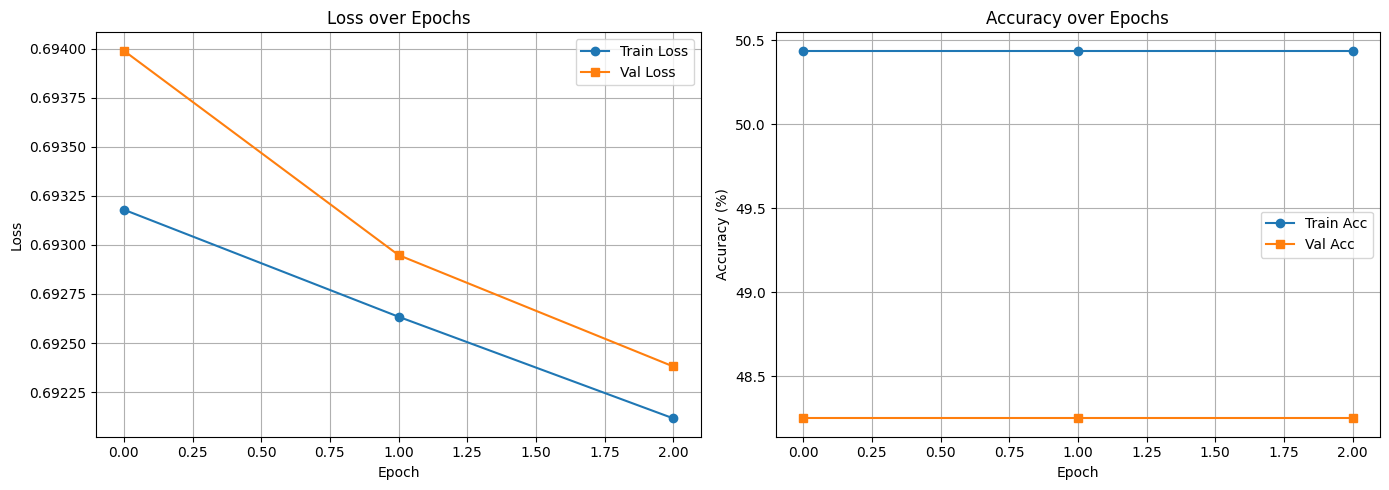


SUMMARY
Final Train Accuracy: 50.44%
Final Val Accuracy: 48.25%

BDH Weight Stats:
  Min: -0.1568, Max: 0.1574
  Mean: -0.0000, Norm: 16.00

BDH Sigma Stats:
  Min: 0.0002, Max: 0.0603
  Mean: 0.0098

INFERENCE TEST

Text: This movie was absolutely fantastic! I loved every minute of it.
Prediction: Negative (confidence: 50.55%)

Text: Terrible film. Waste of time and money. Do not watch.
Prediction: Negative (confidence: 50.83%)


In [2]:
# ========== Installation (run first if needed) ==========
# !pip install transformers datasets torch torchvision tqdm -q

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm import tqdm

# ========== BDH Hebbian Layer ==========
class BDHHebbianLayer(nn.Module):
    def __init__(self, input_dim, output_dim, lambda_decay=0.99, eta=0.001, lr=0.0001):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.lambda_decay = lambda_decay
        self.eta = eta
        self.lr = lr
        
        # Initialize weights v_t with Xavier initialization
        self.v = nn.Parameter(torch.randn(output_dim, input_dim) * np.sqrt(2.0 / input_dim))
        
        # Initialize sigma (moving average)
        self.register_buffer('sigma', torch.ones(output_dim) * 0.01)
    
    def forward(self, input_batch):
        """
        BDH Core Math:
        x_t = ReLU(f(v_t))
        σ_t = λσ_{t-1} + η E[x_t]
        y_t = ReLU(x_t ⊙ σ_t)
        v_{t+1} = v_t + g(y_t)
        """
        batch_size = input_batch.shape[0]
        
        # Step 1: x_t = ReLU(f(v_t))
        x_t = F.relu(F.linear(input_batch, self.v))
        
        # Step 2: σ_t = λσ_{t-1} + η E[x_t]
        with torch.no_grad():
            x_t_mean = x_t.mean(dim=0)
            self.sigma = self.lambda_decay * self.sigma + self.eta * x_t_mean
            self.sigma = torch.clamp(self.sigma, 0.0, 10.0)
        
        # Step 3: y_t = ReLU(x_t ⊙ σ_t)
        y_t = F.relu(x_t * self.sigma.unsqueeze(0))
        
        # Step 4: v_{t+1} = v_t + g(y_t) - Hebbian update
        if self.training:
            with torch.no_grad():
                delta_v = torch.mm(y_t.t(), input_batch) / batch_size
                delta_v = torch.clamp(delta_v, -1.0, 1.0)
                self.v.data += self.lr * delta_v
                
                # CRITICAL: L2 normalize weights
                norms = torch.norm(self.v.data, p=2, dim=1, keepdim=True)
                self.v.data = self.v.data / (norms + 1e-8)
        
        return y_t


# ========== LLM + BDH Model ==========
class LLM_BDH_Classifier(nn.Module):
    def __init__(self, model_name, bdh_dim, num_classes, freeze_llm=True):
        super().__init__()
        
        # Load pretrained LLM with error handling
        try:
            self.llm = AutoModel.from_pretrained(model_name)
        except Exception as e:
            print(f"Standard loading failed: {e}")
            print("Trying with cache directory...")
            self.llm = AutoModel.from_pretrained(model_name, cache_dir="./cache")
        
        self.hidden_size = self.llm.config.hidden_size
        
        # Freeze LLM weights if specified
        if freeze_llm:
            for param in self.llm.parameters():
                param.requires_grad = False
            print(f"LLM weights frozen (not trainable)")
        
        # BDH Hebbian Layer
        self.bdh_layer = BDHHebbianLayer(self.hidden_size, bdh_dim)
        
        # Classification head
        self.classifier = nn.Linear(bdh_dim, num_classes)
        
    def forward(self, input_ids, attention_mask):
        # Get LLM embeddings (use CLS token or mean pooling)
        outputs = self.llm(input_ids=input_ids, attention_mask=attention_mask)
        
        # Mean pooling over sequence length
        hidden_states = outputs.last_hidden_state  # [batch, seq_len, hidden_size]
        mask_expanded = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
        sum_embeddings = torch.sum(hidden_states * mask_expanded, 1)
        sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
        pooled = sum_embeddings / sum_mask  # [batch, hidden_size]
        
        # Apply BDH layer
        bdh_out = self.bdh_layer(pooled)
        
        # Classify
        logits = self.classifier(bdh_out)
        return logits


# ========== Data Preparation ==========
def prepare_data(tokenizer, max_length=128, num_samples=5000):
    """Load and prepare IMDb sentiment dataset"""
    print("Loading IMDb dataset...")
    try:
        dataset = load_dataset("imdb", split="train")
    except Exception as e:
        print(f"Error loading dataset: {e}")
        print("Trying with cache...")
        dataset = load_dataset("imdb", split="train", cache_dir="./cache")
    
    # Take subset for faster training on Kaggle
    dataset = dataset.shuffle(seed=42).select(range(min(num_samples, len(dataset))))
    
    # Split into train/val
    train_size = int(0.8 * len(dataset))
    train_data = dataset.select(range(train_size))
    val_data = dataset.select(range(train_size, len(dataset)))
    
    print(f"Processing {len(train_data)} training samples...")
    print(f"Processing {len(val_data)} validation samples...")
    
    def tokenize_data(data):
        # Convert to lists explicitly
        texts = [item for item in data["text"]]
        labels = [item for item in data["label"]]
        
        print(f"Tokenizing {len(texts)} samples...")
        encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt"
        )
        
        return TensorDataset(
            encodings["input_ids"],
            encodings["attention_mask"],
            torch.tensor(labels, dtype=torch.long)
        )
    
    train_dataset = tokenize_data(train_data)
    val_dataset = tokenize_data(val_data)
    
    return train_dataset, val_dataset


# ========== Training Function ==========
def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=3):
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    
    for epoch in range(epochs):
        # Training
        model.train()
        total_loss, correct, total = 0, 0, 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for batch_idx, (input_ids, attention_mask, labels) in enumerate(pbar):
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            try:
                outputs = model(input_ids, attention_mask)
                loss = criterion(outputs, labels)
                
                # Check for NaN
                if torch.isnan(loss):
                    print(f"\nWarning: NaN loss at batch {batch_idx}, skipping...")
                    continue
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                
                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
                # Update progress bar
                pbar.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'acc': f'{100.*correct/total:.2f}%'
                })
            except RuntimeError as e:
                print(f"\nError at batch {batch_idx}: {e}")
                print("Skipping batch...")
                continue
        
        train_loss = total_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Validation
        val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
        print(f"Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
        
        # Print BDH stats
        w_norm = model.bdh_layer.v.data.norm().item()
        sigma_mean = model.bdh_layer.sigma.mean().item()
        print(f"BDH - W_norm: {w_norm:.2f}, Sigma_mean: {sigma_mean:.4f}\n")
    
    return train_losses, train_accs, val_losses, val_accs


# ========== Evaluation Function ==========
def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    
    with torch.no_grad():
        for input_ids, attention_mask, labels in data_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)
            
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    avg_loss = total_loss / len(data_loader)
    accuracy = 100. * correct / total
    
    return avg_loss, accuracy


# ========== Main Execution ==========
def main():
    # Hyperparameters
    model_name = "distilbert-base-uncased"  # Fast and good for Kaggle
    # Alternative: "mistralai/Mistral-7B-v0.1" (requires more memory)
    
    bdh_dim = 256
    num_classes = 2  # Binary sentiment classification
    batch_size = 16
    epochs = 3
    max_length = 128
    num_samples = 2000  # Reduced for Kaggle stability (increase if you have resources)
    
    # BDH hyperparameters
    bdh_lr = 0.0001
    lambda_decay = 0.99
    eta = 0.001
    
    # Learning rates
    classifier_lr = 0.001
    
    # Device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')
    if torch.cuda.is_available():
        print(f'GPU: {torch.cuda.get_device_name(0)}')
        print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB\n')
    
    # Load tokenizer
    print(f"Loading tokenizer for {model_name}...")
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
    except Exception as e:
        print(f"Error loading tokenizer: {e}")
        print("Retrying with cache...")
        tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir="./cache")
    
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    print("Tokenizer loaded successfully!")
    
    # Prepare data
    train_dataset, val_dataset = prepare_data(tokenizer, max_length, num_samples)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    print(f"\nDataset sizes:")
    print(f"Train: {len(train_dataset)} samples")
    print(f"Val: {len(val_dataset)} samples")
    
    # Create model
    print(f"\nLoading {model_name}...")
    try:
        model = LLM_BDH_Classifier(model_name, bdh_dim, num_classes, freeze_llm=True)
    except Exception as e:
        print(f"Error loading model: {e}")
        print("Retrying with cache...")
        model = LLM_BDH_Classifier(model_name, bdh_dim, num_classes, freeze_llm=True)
    
    # Set BDH hyperparameters
    model.bdh_layer.lr = bdh_lr
    model.bdh_layer.lambda_decay = lambda_decay
    model.bdh_layer.eta = eta
    
    model = model.to(device)
    
    # Clear cache if using CUDA
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    print(f"\nModel loaded successfully!")
    print(f"Model Architecture:")
    print(f"  LLM: {model_name} (frozen)")
    print(f"  LLM Hidden Size: {model.hidden_size}")
    print(f"  BDH Layer: {model.hidden_size} -> {bdh_dim}")
    print(f"  Classifier: {bdh_dim} -> {num_classes}")
    print(f"\nBDH Params: lr={bdh_lr}, lambda={lambda_decay}, eta={eta}")
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTotal parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Optimizer (only for classifier head, BDH updates itself)
    optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=classifier_lr)
    criterion = nn.CrossEntropyLoss()
    
    # Training
    print("\n" + "="*50)
    print("TRAINING")
    print("="*50)
    train_losses, train_accs, val_losses, val_accs = train_model(
        model, train_loader, val_loader, optimizer, criterion, device, epochs
    )
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    axes[0].plot(train_losses, label='Train Loss', marker='o')
    axes[0].plot(val_losses, label='Val Loss', marker='s')
    axes[0].set_title('Loss over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Accuracy plot
    axes[1].plot(train_accs, label='Train Acc', marker='o')
    axes[1].plot(val_accs, label='Val Acc', marker='s')
    axes[1].set_title('Accuracy over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Final summary
    print("\n" + "="*50)
    print("SUMMARY")
    print("="*50)
    print(f"Final Train Accuracy: {train_accs[-1]:.2f}%")
    print(f"Final Val Accuracy: {val_accs[-1]:.2f}%")
    
    w_stats = model.bdh_layer.v.data
    print(f"\nBDH Weight Stats:")
    print(f"  Min: {w_stats.min():.4f}, Max: {w_stats.max():.4f}")
    print(f"  Mean: {w_stats.mean():.4f}, Norm: {w_stats.norm():.2f}")
    
    sigma_stats = model.bdh_layer.sigma
    print(f"\nBDH Sigma Stats:")
    print(f"  Min: {sigma_stats.min():.4f}, Max: {sigma_stats.max():.4f}")
    print(f"  Mean: {sigma_stats.mean():.4f}")
    
    # Test inference
    print("\n" + "="*50)
    print("INFERENCE TEST")
    print("="*50)
    test_texts = [
        "This movie was absolutely fantastic! I loved every minute of it.",
        "Terrible film. Waste of time and money. Do not watch."
    ]
    
    model.eval()
    try:
        with torch.no_grad():
            encodings = tokenizer(
                test_texts,
                truncation=True,
                padding="max_length",
                max_length=max_length,
                return_tensors="pt"
            )
            input_ids = encodings["input_ids"].to(device)
            attention_mask = encodings["attention_mask"].to(device)
            
            outputs = model(input_ids, attention_mask)
            probs = F.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1)
            
            for i, text in enumerate(test_texts):
                sentiment = "Positive" if predictions[i] == 1 else "Negative"
                confidence = probs[i][predictions[i]].item() * 100
                print(f"\nText: {text}")
                print(f"Prediction: {sentiment} (confidence: {confidence:.2f}%)")
    except Exception as e:
        print(f"Inference test failed: {e}")
        print("Model training completed, but inference test had issues.")

# Run everything
if __name__ == '__main__':
    main()

Purely unsupervised Hebbian plasticity can erase supervised structure in pretrained representations.

In [8]:
# ============================================================
# KDSH 2026 – Track B
# BDH-Lite State-Space Surprisal (FULL FIXED VERSION)
# ============================================================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
# ============================================================
# CONFIG
# ============================================================
DATA_DIR = "/kaggle/input/kdshdata"
TRAIN_CSV = f"{DATA_DIR}/train.csv"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ENCODER_NAME = "sentence-transformers/all-MiniLM-L6-v2"
STATE_DIM = 512
TOPK_FRAC = 0.05
ALPHA = 0.05
CHUNK_SIZE = 256 # larger chunk = faster
DEBUG = True
print(f"[INFO] Device: {DEVICE}")
# ============================================================
# LOAD & ANALYZE DATASET
# ============================================================
df = pd.read_csv(TRAIN_CSV)
print("\n[DATASET INFO]")
print(df.info())
print("\n[LABEL DISTRIBUTION]")
print(df["label"].value_counts())
LABEL_MAP = {"consistent": 1, "contradict": 0}
df["label_id"] = df["label"].map(LABEL_MAP)
# ============================================================
# BUILD CASE-SAFE NOVEL FILE MAP
# ============================================================
AVAILABLE_NOVELS = {
    f.lower(): f
    for f in os.listdir(DATA_DIR)
    if f.endswith(".txt")
}
print("\n[INFO] Available novel files:")
for v in AVAILABLE_NOVELS.values():
    print(" ", v)
# ============================================================
# LOAD ENCODER (FROZEN)
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(ENCODER_NAME)
encoder = AutoModel.from_pretrained(ENCODER_NAME).to(DEVICE)
encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False
EMB_DIM = encoder.config.hidden_size
# ============================================================
# STREAMING TOKEN CHUNKING (NO WARNING)
# ============================================================
def chunk_text(text, chunk_size):
    enc = tokenizer(
        text,
        add_special_tokens=False,
        truncation=True,
        return_attention_mask=False,
        return_overflowing_tokens=True,
        max_length=chunk_size,
        stride=chunk_size - 3,  # To avoid stride >= effective max_length error
    )
    for ids in enc["input_ids"]:
        yield ids
@torch.no_grad()
def encode_chunk(token_ids):
    ids = torch.tensor(token_ids).unsqueeze(0).to(DEVICE)
    mask = torch.ones_like(ids)
    out = encoder(input_ids=ids, attention_mask=mask)
    return out.last_hidden_state.mean(dim=1).squeeze(0)
# ============================================================
# BDH-LITE CELL
# ============================================================
class BDHLiteCell(nn.Module):
    def __init__(self, d_in, d_state, topk_frac):
        super().__init__()
        self.W_in = nn.Linear(d_in, d_state, bias=False)
        self.W_rec = nn.Linear(d_state, d_state, bias=False)
        self.topk_frac = topk_frac
        nn.init.xavier_uniform_(self.W_in.weight)
        nn.init.xavier_uniform_(self.W_rec.weight)
    def forward(self, x, h):
        z = self.W_in(x) + self.W_rec(h)
        a = F.relu(z)
        k = max(1, int(self.topk_frac * a.numel()))
        vals, idx = torch.topk(a, k)
        sparse = torch.zeros_like(a)
        sparse[idx] = vals
        h_new = (1 - ALPHA) * h + ALPHA * sparse
        return h_new, sparse
class SurprisalHead(nn.Module):
    def __init__(self, d_state, d_emb):
        super().__init__()
        self.proj = nn.Linear(d_state, d_emb)
    def forward(self, h):
        return self.proj(h)
cell = BDHLiteCell(EMB_DIM, STATE_DIM, TOPK_FRAC).to(DEVICE)
surprisal_head = SurprisalHead(STATE_DIM, EMB_DIM).to(DEVICE)
# ============================================================
# NOVEL STATE CACHE (CRITICAL SPEED FIX)
# ============================================================
NOVEL_STATE_CACHE = {}
@torch.no_grad()
def assimilate_novel(novel_text):
    h = torch.zeros(STATE_DIM, device=DEVICE)
    active_ratios = []
    for chunk in chunk_text(novel_text, CHUNK_SIZE):
        x = encode_chunk(chunk)
        h, sparse = cell(x, h)
        active_ratios.append((sparse > 0).float().mean().item())
    if DEBUG:
        print(f"[DEBUG] Novel avg active neurons: {sum(active_ratios)/len(active_ratios):.4f}")
    return h.detach()
def get_novel_state(book_name):
    key = f"{book_name}.txt".lower()
    if key not in AVAILABLE_NOVELS:
        raise ValueError(f"Novel file not found for: {book_name}")
    if key in NOVEL_STATE_CACHE:
        if DEBUG:
            print(f"[CACHE] Using cached state for {book_name}")
        return NOVEL_STATE_CACHE[key]
    novel_path = os.path.join(DATA_DIR, AVAILABLE_NOVELS[key])
    with open(novel_path, "r", encoding="utf-8") as f:
        novel_text = f.read()
    h = assimilate_novel(novel_text)
    NOVEL_STATE_CACHE[key] = h
    return h
# ============================================================
# BACKSTORY SURPRISAL
# ============================================================
@torch.no_grad()
def compute_surprisal(backstory_text, h_init):
    h = h_init.clone()
    scores = []
    chunks = list(chunk_text(backstory_text, CHUNK_SIZE))
    if len(chunks) < 2:
        return 0.0
    for i in range(len(chunks) - 1):
        x = encode_chunk(chunks[i])
        x_next = encode_chunk(chunks[i + 1])
        h, _ = cell(x, h)
        pred = surprisal_head(h)
        scores.append(F.mse_loss(pred, x_next).item())
    mean_s = sum(scores) / len(scores)
    if DEBUG:
        print(f"[DEBUG] Backstory surprisal: {mean_s:.4f}")
    return mean_s
# ============================================================
# 80 / 20 SPLIT
# ============================================================
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"]
)
print(f"\n[INFO] Train size: {len(train_df)}")
print(f"[INFO] Val size: {len(val_df)}")
# ============================================================
# TRAIN THRESHOLD
# ============================================================
train_scores = []
print("\n[INFO] Computing surprisal on TRAIN split...\n")
for row in tqdm(train_df.itertuples(), total=len(train_df)):
    h_novel = get_novel_state(row.book_name)
    s = compute_surprisal(row.content, h_novel)
    train_scores.append(s)
train_df["surprisal"] = train_scores
pos = train_df[train_df.label_id == 1].surprisal.mean()
neg = train_df[train_df.label_id == 0].surprisal.mean()
threshold = (pos + neg) / 2
print(f"\n[INFO] Threshold: {threshold:.4f}")
print(f"[INFO] Mean surprisal | consistent: {pos:.4f}")
print(f"[INFO] Mean surprisal | contradict: {neg:.4f}")
# ============================================================
# VALIDATION
# ============================================================
y_true, y_pred = [], []
print("\n[INFO] Evaluating on VAL split...\n")
for row in tqdm(val_df.itertuples(), total=len(val_df)):
    h_novel = get_novel_state(row.book_name)
    s = compute_surprisal(row.content, h_novel)
    y_true.append(row.label_id)
    y_pred.append(1 if s < threshold else 0)
# ============================================================
# METRICS
# ============================================================
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
print("\n" + "="*60)
print("VALIDATION RESULTS (20% SPLIT)")
print("="*60)
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

[INFO] Device: cuda

[DATASET INFO]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         80 non-null     int64 
 1   book_name  80 non-null     object
 2   char       80 non-null     object
 3   caption    31 non-null     object
 4   content    80 non-null     object
 5   label      80 non-null     object
dtypes: int64(1), object(5)
memory usage: 3.9+ KB
None

[LABEL DISTRIBUTION]
label
consistent    51
contradict    29
Name: count, dtype: int64

[INFO] Available novel files:
  In search of the castaways.txt
  The Count of Monte Cristo.txt

[INFO] Train size: 64
[INFO] Val size: 16

[INFO] Computing surprisal on TRAIN split...



  2%|▏         | 1/64 [16:31<17:20:44, 991.18s/it]

[DEBUG] Novel avg active neurons: 0.0488
[CACHE] Using cached state for The Count of Monte Cristo
[CACHE] Using cached state for The Count of Monte Cristo
[CACHE] Using cached state for The Count of Monte Cristo
[CACHE] Using cached state for The Count of Monte Cristo
[CACHE] Using cached state for The Count of Monte Cristo
[CACHE] Using cached state for The Count of Monte Cristo


100%|██████████| 64/64 [21:22<00:00, 20.03s/it]   


[DEBUG] Novel avg active neurons: 0.0488
[CACHE] Using cached state for The Count of Monte Cristo
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for The Count of Monte Cristo
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for The Count of Monte Cristo
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for The Count of Monte Cristo
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for In S

100%|██████████| 16/16 [00:00<00:00, 2856.30it/s]

[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for The Count of Monte Cristo
[CACHE] Using cached state for The Count of Monte Cristo
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for The Count of Monte Cristo
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for The Count of Monte Cristo
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for The Count of Monte Cristo
[CACHE] Using cached state for The Count of Monte Cristo
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for In Search of the Castaways
[CACHE] Using cached state for The Count of Monte Cristo

VALIDATION RESULTS (20% SPLIT)
Accuracy : 0.3750
F1 Score : 0.0000

Confusion 


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [9]:
# ============================================================
# KDSH 2026 – Track B (FINAL CORRECT VERSION)
# BDH-Lite State-Space Incompatibility Detector
# ============================================================

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# ============================================================
# CONFIG
# ============================================================

DATA_DIR = "/kaggle/input/kdshdata"
TRAIN_CSV = f"{DATA_DIR}/train.csv"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ENCODER_NAME = "sentence-transformers/all-MiniLM-L6-v2"

STATE_DIM = 512
TOPK_FRAC = 0.05
ALPHA = 0.05
CHUNK_SIZE = 256

DEBUG = True

print(f"[INFO] Device: {DEVICE}")

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(TRAIN_CSV)

print("\n[DATASET INFO]")
print(df.info())

LABEL_MAP = {"consistent": 1, "contradict": 0}
df["label_id"] = df["label"].map(LABEL_MAP)

print("\n[LABEL DISTRIBUTION]")
print(df["label"].value_counts())

# ============================================================
# BUILD CASE-SAFE NOVEL MAP
# ============================================================

AVAILABLE_NOVELS = {
    f.lower(): f
    for f in os.listdir(DATA_DIR)
    if f.endswith(".txt")
}

print("\n[INFO] Available novel files:")
for v in AVAILABLE_NOVELS.values():
    print(" ", v)

# ============================================================
# LOAD ENCODER (FROZEN)
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(ENCODER_NAME)
encoder = AutoModel.from_pretrained(ENCODER_NAME).to(DEVICE)
encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False

EMB_DIM = encoder.config.hidden_size

# ============================================================
# STREAMING CHUNKING (SAFE)
# ============================================================

def chunk_text(text, chunk_size):
    enc = tokenizer(
        text,
        add_special_tokens=False,
        truncation=True,
        return_attention_mask=False,
        return_overflowing_tokens=True,
        max_length=chunk_size,
        stride=chunk_size - 4,
    )
    for ids in enc["input_ids"]:
        yield ids

@torch.no_grad()
def encode_chunk(token_ids):
    ids = torch.tensor(token_ids).unsqueeze(0).to(DEVICE)
    mask = torch.ones_like(ids)
    out = encoder(input_ids=ids, attention_mask=mask)
    return out.last_hidden_state.mean(dim=1).squeeze(0)

# ============================================================
# BDH-LITE CELL
# ============================================================

class BDHLiteCell(nn.Module):
    def __init__(self, d_in, d_state, topk_frac):
        super().__init__()
        self.W_in = nn.Linear(d_in, d_state, bias=False)
        self.W_rec = nn.Linear(d_state, d_state, bias=False)
        self.topk_frac = topk_frac
        nn.init.xavier_uniform_(self.W_in.weight)
        nn.init.xavier_uniform_(self.W_rec.weight)

    def forward(self, x, h):
        z = self.W_in(x) + self.W_rec(h)
        a = F.relu(z)

        k = max(1, int(self.topk_frac * a.numel()))
        vals, idx = torch.topk(a, k)

        sparse = torch.zeros_like(a)
        sparse[idx] = vals

        h_new = (1 - ALPHA) * h + ALPHA * sparse
        return h_new, sparse

cell = BDHLiteCell(EMB_DIM, STATE_DIM, TOPK_FRAC).to(DEVICE)

# ============================================================
# NOVEL STATE CACHE
# ============================================================

NOVEL_STATE_CACHE = {}

@torch.no_grad()
def assimilate_novel(novel_text):
    h = torch.zeros(STATE_DIM, device=DEVICE)
    active = []

    for chunk in chunk_text(novel_text, CHUNK_SIZE):
        x = encode_chunk(chunk)
        h, sparse = cell(x, h)
        active.append((sparse > 0).float().mean().item())

    if DEBUG:
        print(f"[DEBUG] Novel avg active neurons: {sum(active)/len(active):.4f}")

    return h.detach()

def get_novel_state(book_name):
    key = f"{book_name}.txt".lower()

    if key not in AVAILABLE_NOVELS:
        raise ValueError(f"Novel not found: {book_name}")

    if key in NOVEL_STATE_CACHE:
        if DEBUG:
            print(f"[CACHE] Using cached state for {book_name}")
        return NOVEL_STATE_CACHE[key]

    novel_path = os.path.join(DATA_DIR, AVAILABLE_NOVELS[key])
    with open(novel_path, "r", encoding="utf-8") as f:
        novel_text = f.read()

    h = assimilate_novel(novel_text)
    NOVEL_STATE_CACHE[key] = h
    return h

# ============================================================
# BACKSTORY INCOMPATIBILITY SURPRISAL (FIXED)
# ============================================================

@torch.no_grad()
def compute_surprisal(backstory_text, h_novel):
    total = 0.0
    count = 0

    proj_state = cell.W_rec(h_novel)

    for chunk in chunk_text(backstory_text, CHUNK_SIZE):
        x = encode_chunk(chunk)
        proj_input = cell.W_in(x)

        s = F.mse_loss(proj_state, proj_input).item()
        total += s
        count += 1

    if count == 0:
        return 0.0

    mean_s = total / count

    if DEBUG:
        print(f"[DEBUG] Backstory incompatibility surprisal: {mean_s:.4f}")

    return mean_s

# ============================================================
# TRAIN / VAL SPLIT
# ============================================================

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"]
)

print(f"\n[INFO] Train size: {len(train_df)}")
print(f"[INFO] Val size:   {len(val_df)}")

# ============================================================
# TRAIN THRESHOLD
# ============================================================

train_scores = []

print("\n[INFO] Computing TRAIN surprisal...\n")

for row in tqdm(train_df.itertuples(), total=len(train_df)):
    h_novel = get_novel_state(row.book_name)
    s = compute_surprisal(row.content, h_novel)
    train_scores.append(s)

train_df["surprisal"] = train_scores

pos = train_df[train_df.label_id == 1].surprisal.mean()
neg = train_df[train_df.label_id == 0].surprisal.mean()
threshold = (pos + neg) / 2

print(f"\n[INFO] Threshold: {threshold:.4f}")
print(f"[INFO] Mean surprisal | consistent: {pos:.4f}")
print(f"[INFO] Mean surprisal | contradict: {neg:.4f}")

# ============================================================
# VALIDATION
# ============================================================

y_true, y_pred = [], []

print("\n[INFO] Evaluating VAL split...\n")

for row in tqdm(val_df.itertuples(), total=len(val_df)):
    h_novel = get_novel_state(row.book_name)
    s = compute_surprisal(row.content, h_novel)
    y_true.append(row.label_id)
    y_pred.append(1 if s < threshold else 0)

# ============================================================
# METRICS
# ============================================================

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("\n" + "="*60)
print("VALIDATION RESULTS (20% SPLIT)")
print("="*60)
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


[INFO] Device: cuda

[DATASET INFO]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         80 non-null     int64 
 1   book_name  80 non-null     object
 2   char       80 non-null     object
 3   caption    31 non-null     object
 4   content    80 non-null     object
 5   label      80 non-null     object
dtypes: int64(1), object(5)
memory usage: 3.9+ KB
None

[LABEL DISTRIBUTION]
label
consistent    51
contradict    29
Name: count, dtype: int64

[INFO] Available novel files:
  In search of the castaways.txt
  The Count of Monte Cristo.txt

[INFO] Train size: 64
[INFO] Val size:   16

[INFO] Computing TRAIN surprisal...



  2%|▏         | 1/64 [12:16<12:53:45, 736.92s/it]

[DEBUG] Novel avg active neurons: 0.0488
[DEBUG] Backstory incompatibility surprisal: 0.0499
[CACHE] Using cached state for The Count of Monte Cristo
[DEBUG] Backstory incompatibility surprisal: 0.0394
[CACHE] Using cached state for The Count of Monte Cristo
[DEBUG] Backstory incompatibility surprisal: 0.0279
[CACHE] Using cached state for The Count of Monte Cristo
[DEBUG] Backstory incompatibility surprisal: 0.0295
[CACHE] Using cached state for The Count of Monte Cristo
[DEBUG] Backstory incompatibility surprisal: 0.0284
[CACHE] Using cached state for The Count of Monte Cristo
[DEBUG] Backstory incompatibility surprisal: 0.0571
[CACHE] Using cached state for The Count of Monte Cristo
[DEBUG] Backstory incompatibility surprisal: 0.0484


 45%|████▌     | 29/64 [15:57<11:23, 19.53s/it]   

[DEBUG] Novel avg active neurons: 0.0488
[DEBUG] Backstory incompatibility surprisal: 0.0212
[CACHE] Using cached state for The Count of Monte Cristo
[DEBUG] Backstory incompatibility surprisal: 0.0294
[CACHE] Using cached state for In Search of the Castaways
[DEBUG] Backstory incompatibility surprisal: 0.0344
[CACHE] Using cached state for In Search of the Castaways
[DEBUG] Backstory incompatibility surprisal: 0.0189
[CACHE] Using cached state for In Search of the Castaways
[DEBUG] Backstory incompatibility surprisal: 0.0232
[CACHE] Using cached state for In Search of the Castaways
[DEBUG] Backstory incompatibility surprisal: 0.0249
[CACHE] Using cached state for The Count of Monte Cristo
[DEBUG] Backstory incompatibility surprisal: 0.0350
[CACHE] Using cached state for In Search of the Castaways
[DEBUG] Backstory incompatibility surprisal: 0.0232
[CACHE] Using cached state for In Search of the Castaways
[DEBUG] Backstory incompatibility surprisal: 0.0208
[CACHE] Using cached state fo

100%|██████████| 64/64 [15:57<00:00, 14.96s/it]


[DEBUG] Backstory incompatibility surprisal: 0.0406
[CACHE] Using cached state for In Search of the Castaways
[DEBUG] Backstory incompatibility surprisal: 0.0414
[CACHE] Using cached state for In Search of the Castaways
[DEBUG] Backstory incompatibility surprisal: 0.0506
[CACHE] Using cached state for The Count of Monte Cristo
[DEBUG] Backstory incompatibility surprisal: 0.0242
[CACHE] Using cached state for The Count of Monte Cristo
[DEBUG] Backstory incompatibility surprisal: 0.0326
[CACHE] Using cached state for In Search of the Castaways
[DEBUG] Backstory incompatibility surprisal: 0.0237
[CACHE] Using cached state for The Count of Monte Cristo
[DEBUG] Backstory incompatibility surprisal: 0.0404
[CACHE] Using cached state for The Count of Monte Cristo
[DEBUG] Backstory incompatibility surprisal: 0.0277
[CACHE] Using cached state for In Search of the Castaways
[DEBUG] Backstory incompatibility surprisal: 0.0230
[CACHE] Using cached state for The Count of Monte Cristo
[DEBUG] Backsto

100%|██████████| 16/16 [00:00<00:00, 205.85it/s]

[CACHE] Using cached state for In Search of the Castaways
[DEBUG] Backstory incompatibility surprisal: 0.0373
[CACHE] Using cached state for The Count of Monte Cristo
[DEBUG] Backstory incompatibility surprisal: 0.0181
[CACHE] Using cached state for The Count of Monte Cristo
[DEBUG] Backstory incompatibility surprisal: 0.0290
[CACHE] Using cached state for In Search of the Castaways
[DEBUG] Backstory incompatibility surprisal: 0.0437
[CACHE] Using cached state for In Search of the Castaways
[DEBUG] Backstory incompatibility surprisal: 0.0171
[CACHE] Using cached state for In Search of the Castaways
[DEBUG] Backstory incompatibility surprisal: 0.0260
[CACHE] Using cached state for The Count of Monte Cristo
[DEBUG] Backstory incompatibility surprisal: 0.0334
[CACHE] Using cached state for In Search of the Castaways
[DEBUG] Backstory incompatibility surprisal: 0.0205
[CACHE] Using cached state for The Count of Monte Cristo
[DEBUG] Backstory incompatibility surprisal: 0.0506
[CACHE] Using 